# Part 4-  Model Distillation / Quantization

## subquestion a.

Originally, we wanted to do distillation process as we found the concept more interesting (and intuitive). Then looking through the class materials we realized that we could leverage some of the content/walk through from a class notebook to at least try quantization.

We then, collaborating with Claude and Google, realized that we could actually stack these two procedures. So that's what we've done. We've started with quantization and then on top of that quantized model, we train a student model.

**Our Goal:** compress our best-performing fine-tuned BERT classifier and quantify the speed / memory / carbon vs. performance trade-off, following the Pruna-based approach from the professor's *Session 7.3* notebook AND distill it into a DistilBERT model as a second step.

In [1]:
import os, sys, gc, json, random, copy
from pathlib import Path
from pruna import SmashConfig, smash
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from utils import preprocess_for_bert, measure_inference_metrics  
from Part_2_BERT import train_bert, tokenizer, max_length     
import matplotlib.pyplot as plt
import setup

os.getcwd()
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

## load data with load and save function
data_path = Path("../data/trustpilot_reviews.pkl")
if data_path.exists():
    df = pd.read_pickle(data_path)
else:
    df = setup.load_dataset_and_save_as_csv() 
df.head()


Skipping import of cpp extensions due to incompatible torch version 2.12.0 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0618 18:54:36.470000 97495 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


In [2]:

SEED = 123
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)



In [3]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "scripts":
    PROJECT_ROOT = PROJECT_ROOT.parent

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {device}")
print(f"Torch        : {torch.__version__}")
print(f"Tokenizer    : bert-base-uncased | max_length={max_length}")

# output dirs
RESULTS_DIR = PROJECT_ROOT / "results"; RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR  = PROJECT_ROOT / "models";  MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "figures"; FIGURES_DIR.mkdir(exist_ok=True)

# --- Part 4c prediction capture (shared by the eval harness) ---
# measure_inference_metrics already returns the per-sample predictions/labels from the single
# forward pass it makes for every variant. We stash them here so the error analysis (Subquestion c
# / Step 14) reuses them instead of re-running inference on each model (~3-5 min/model on CPU).
# Kept OUT of the metrics JSON to avoid bloating it with 2k ints per variant, and mirrored to an
# .npz so a kernel restart can reload them without re-inferring.
PRED_KEYS     = ("predictions", "labels")
PREDS_FILE    = RESULTS_DIR / "part4_variant_preds.npz"
variant_preds = {}        # name -> np.ndarray of hard predictions on test_ds
pred_labels   = None      # np.ndarray of true labels (identical across variants)

def capture_preds(name, metrics):
    """Pop per-sample preds/labels out of a metrics dict into variant_preds (and mirror to .npz).

    Mutates `metrics` in place (removing the two large keys) so the caller's results JSON stays
    compact. Returns `metrics` for convenience. No-op if the metrics carry no predictions.
    """
    global pred_labels
    preds  = metrics.pop("predictions", None)
    labels = metrics.pop("labels", None)
    if preds is None:
        return metrics                          # older harness / nothing captured
    variant_preds[name] = np.asarray(preds)
    if labels is not None:
        pred_labels = np.asarray(labels)        # same for every variant; keep the latest
    # mirror to disk so Step 14 survives a kernel restart (reserved "__labels__" key for y_true)
    np.savez(PREDS_FILE, __labels__=pred_labels, **variant_preds)
    return metrics

Project root : /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final
Device       : cpu
Torch        : 2.12.0
Tokenizer    : bert-base-uncased | max_length=64


### Load data with the *same* test split as Parts 1–3

In [4]:
CATEGORIES = ["Travel & Vacation", "Media & Publishing"]

# Use the EXACT same data + split as Part 3 best_bert_100 teacher.
# Part 3 (Part_3.ipynb) trains/saves the teacher from the pre-cut 100% CSV: the seed-42
# reshuffle is already baked into filtered_reviews_100percent.csv by setup_part3, so Part 3
# just reads that CSV and splits with random_state=SEED. We reproduce that here.
# NOTE: do NOT rebuild the split from trustpilot_reviews.pkl with a different shuffle seed --

df = pd.read_csv(PROJECT_ROOT / "data" / "filtered_reviews_100percent.csv")

# Same preprocessing + labeling as Part 3.
df["review"] = df["review"].apply(preprocess_for_bert)
labeled_df = df.dropna(subset=["stars", "review"])
texts  = labeled_df["review"].tolist()
labels = (labeled_df["stars"].astype(int) - 1).tolist()   # 0-4 for 5 classes
num_labels = 5

set_seed(SEED)
train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=SEED
)

print(f"Total labeled : {len(texts)}")
print(f"Train         : {len(train_texts)}")
print(f"Test (valid)  : {len(valid_texts)}")
print("Test label distribution (0-4):")
print(pd.Series(valid_labels).value_counts().sort_index())


Total labeled : 10776
Train         : 8620
Test (valid)  : 2156
Test label distribution (0-4):
0    436
1    402
2    415
3    441
4    462
Name: count, dtype: int64


In [5]:
from transformers import AutoModelForSequenceClassification

TEACHER_DIR = MODELS_DIR / "best_bert_100"
TEACHER_EPOCHS = 3          # raise to ~10 on GPU for a stronger teacher
RETRAIN = True             # set True to force retraining even if a saved teacher exists

if TEACHER_DIR.exists() and not RETRAIN:
    print(f"Loading existing teacher from {TEACHER_DIR}")
    teacher = AutoModelForSequenceClassification.from_pretrained(TEACHER_DIR)
else:
    print(f"Training teacher (BERT @ 100% data, {TEACHER_EPOCHS} epochs)...")
    set_seed(SEED)
    teacher, _, _ = train_bert(
        train_texts, train_labels, valid_texts, valid_labels,
        num_train_epochs=TEACHER_EPOCHS,
        num_labels=num_labels,
        early_stopping=True,                 # train split is > 500 examples
        output_dir=str(PROJECT_ROOT / "tmp_best_100_teacher"),
    )
    teacher.save_pretrained(TEACHER_DIR)
    tokenizer.save_pretrained(TEACHER_DIR)
    print(f"Saved teacher to {TEACHER_DIR}")

teacher.to(device).eval()
n_params = sum(p.numel() for p in teacher.parameters())
print(f"Teacher parameters: {n_params:,}")

Training teacher (BERT @ 100% data, 3 epochs)...


Map:   0%|          | 0/8620 [00:00<?, ? examples/s]

Map:   0%|          | 0/2156 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.153100,1.029054
2,0.848100,1.091433
3,0.536600,1.277404


/Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saved teacher to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/models/best_bert_100
Teacher parameters: 109,486,085


We either manually save the best results for part 3 as "best_teacher_100" or retrain it here once via the shared `train_bert` (identical architecture, tokenizer, and hyper-parameters as Part 3) and **save it** to `models/best_100_teacher/` so the rest of Part 4can load it directly.

`load_best_model_at_end=True` inside `train_bert` means the returned model is the best checkpoint by validation loss.

measure_inference_metrics (from `utils.py` from the class notebook) iterates the dataset in fixed-size batches and stacks each batch into tensors, so the test set must be tokenized to a **fixed length** (padded and consistent with what we've done in other notebooks) and exposed with the columns `input_ids`, `attention_mask`, `label`. We pad to the same `max_length=64` the model was trained with.

In [6]:
from datasets import Dataset as HFDataset

def build_eval_dataset(texts, labels):
    ds = HFDataset.from_dict({"text": list(texts), "label": list(labels)})
    def tok(batch):
        return tokenizer(batch["text"], padding="max_length",
                         truncation=True, max_length=max_length)
    ds = ds.map(tok, batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    return ds

test_ds = build_eval_dataset(valid_texts, valid_labels)
print(test_ds)
print("Sanity — one batch shapes:")
b = test_ds[0:4]
print(" input_ids     :", b["input_ids"].shape)
print(" attention_mask:", b["attention_mask"].shape)
print(" label         :", b["label"].shape)

Map:   0%|          | 0/2156 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2156
})
Sanity — one batch shapes:
 input_ids     : torch.Size([4, 64])
 attention_mask: torch.Size([4, 64])
 label         : torch.Size([4])


We run `measure_inference_metrics` on the teacher to capture the full baseline: (1) F1 (2) precision (3) recall (macro), (4) inference speed (samples/sec), RAM, GPU memory (only populated when CUDA is available), and carbon footprint via codecarbon (consistent with class notebook)

In [7]:
BATCH_SIZE = 32

print("Evaluating ORIGINAL (teacher) model...")
baseline_metrics = measure_inference_metrics(
    teacher, test_ds, device=device, batch_size=BATCH_SIZE
)
baseline_metrics["n_params"] = int(n_params)
baseline_metrics["n_test_samples"] = len(test_ds)

print("\n" + "=" * 52)
print("ORIGINAL BERT — BASELINE METRICS")
print("=" * 52)
print("\nClassification (macro):")
for k in ("accuracy","f1_macro", "precision_macro", "recall_macro"):
    print(f"  {k:18s}: {baseline_metrics[k]:.4f}")
print("\nEfficiency:")
print(f"  inference_speed   : {baseline_metrics['inference_speed (samples/sec)']:.2f} samples/sec")
print(f"  cpu_memory_peak   : {baseline_metrics['cpu_memory_peak (MB)']:.1f} MB")
if 'gpu_memory_used (MB)' in baseline_metrics:
    print(f"  gpu_memory_used   : {baseline_metrics['gpu_memory_used (MB)']:.1f} MB")
print(f"  carbon_footprint  : {baseline_metrics['carbon_footprint (kg CO2eq)']:.8f} kg CO2eq")
print(f"  parameters        : {baseline_metrics['n_params']:,}")

# Stash the teacher's per-sample predictions from this single pass (reused in Step 14) and drop
# them from baseline_metrics so the JSON below stays compact.
capture_preds("original", baseline_metrics)

# Persist so later steps / kernel restarts don't lose the baseline.
results = {"original": baseline_metrics}
with open(RESULTS_DIR / "part4_baseline.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved baseline to {RESULTS_DIR / 'part4_baseline.json'}")
print(f"Stashed 'original' predictions ({len(variant_preds['original'])}) -> {PREDS_FILE.name}")

Evaluating ORIGINAL (teacher) model...


100%|██████████| 68/68 [00:37<00:00,  1.83it/s]



ORIGINAL BERT — BASELINE METRICS

Classification (macro):
  accuracy          : 0.5575
  f1_macro          : 0.5475
  precision_macro   : 0.5466
  recall_macro      : 0.5512

Efficiency:
  inference_speed   : 58.02 samples/sec
  cpu_memory_peak   : 1362.8 MB
  carbon_footprint  : 0.00008175 kg CO2eq
  parameters        : 109,486,085

Saved baseline to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/results/part4_baseline.json
Stashed 'original' predictions (2156) -> part4_variant_preds.npz


### Same evaluation method

One wrapper around the metrics function so every variant (baseline + each compressed model) is benchmarked **identically** on the same test set, recorded into a single "results" dict, and saved.

In [8]:
import tempfile, shutil

RESULTS_FILE = RESULTS_DIR / "part4_compression_results.json"

## cumulative results dict, seeded with the Step 1 baseline
results = {"original": baseline_metrics}

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model): ## updated to show size, before it was failing because previous code couldn't account for anything other than plan `float32` tensors
    tmp = tempfile.mkdtemp()
    try:
        try:
            model.save_pretrained(tmp)          # works for normal HF models
        except Exception:
            torch.save(model.state_dict(),       # fallback for quantized models
                       os.path.join(tmp, "model.pt"))
        total = sum(
            os.path.getsize(os.path.join(root, f))
            for root, _, files in os.walk(tmp) for f in files
        )
        return total / (1024 * 1024)
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


def evaluate_variant(model, name, batch_size=BATCH_SIZE, save=True):
    """Benchmark one model variant on the shared test set and record it."""
    ## same function, same test_ds, same batch size for every variant
    m = measure_inference_metrics(model, test_ds, device=device, batch_size=batch_size)
    ## stash the per-sample predictions from this pass (reused in Step 14) and drop them from `m`
    ## so the results JSON stays compact — confusion matrices then need NO second inference pass.
    capture_preds(name, m)
    m["n_params"] = int(count_params(model))
    m["size_mb"] = model_size_mb(model)          # measured while the model is still alive
    m["n_test_samples"] = len(test_ds)
    results[name] = m

    if save:
        with open(RESULTS_FILE, "w") as f:
            json.dump(results, f, indent=2)

    ## compact, consistent summary
    size_str = f"{m['size_mb']:.1f} MB" if m["size_mb"] is not None else "n/a"
    print(f"[{name}]")
    print(f"  accuracy          : {m['accuracy']:.4f}")
    print(f"  f1_macro          : {m['f1_macro']:.4f}")
    print(f"  precision_macro   : {m['precision_macro']:.4f}")
    print(f"  recall_macro      : {m['recall_macro']:.4f}")
    print(f"  inference_speed   : {m['inference_speed (samples/sec)']:.2f} samples/sec")
    print(f"  cpu_memory_peak   : {m['cpu_memory_peak (MB)']:.1f} MB")
    if "gpu_memory_used (MB)" in m:
        print(f"  gpu_memory_used   : {m['gpu_memory_used (MB)']:.1f} MB")
    print(f"  carbon_footprint  : {m['carbon_footprint (kg CO2eq)']:.8f} kg CO2eq")
    print(f"  parameters        : {m['n_params']:,}")
    print(f"  size_on_disk      : {size_str}")
    return m

## give the baseline its on-disk size too (teacher is still in memory at this point)
baseline_metrics.setdefault("size_mb", model_size_mb(teacher))

## persist the baseline through the same path the variants will use
with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)
print(f"Harness ready. Baseline recorded as 'original'. Saving to {RESULTS_FILE.name}")

Harness ready. Baseline recorded as 'original'. Saving to part4_compression_results.json


**Define Pruna compression strategies**

Mirror professor's notebook on pruna configurations

In [9]:
## each strategy: name, the SmashConfig algo dict, GPU requirement flag, short description
## applied in Step 4 on a fresh deepcopy of the teacher
compression_strategies = [
    {
        "name": "unstructured_pruning",
        "config": {"pruner": "torch_unstructured"},
        "needs_cuda": False,
        "description": "Unstructured magnitude pruning (zeros individual weights)",
    },
        # {
        # "name": "half_precision", ### This will crash as it will convert all values, including indices
        # "config_fn": lambda: {    ## it is meant to reduce the quantities (weights, activations, logits),
        #     "quantizer": "half"    ## but it impacts all numbers/quantities, including token index values.
        # },
        # "requires": [],
        # "description": "Half precision (FP16) quantization"
    # },
    {
        "name": "dynamic_quantization",
        "config": {"quantizer": "torch_dynamic"},
        "needs_cuda": False,
        "description": "Dynamic INT8 quantization at runtime (CPU-friendly)",
        
    },
    {
        "name": "llm_int8_quantization",
        "config": {"quantizer": "llm_int8"},
        "needs_cuda": True,
        "description": "Mixed-precision INT8 with outlier handling (needs CUDA + bitsandbytes)",
    },
    {
        "name": "structured_pruning",
        "config": {"pruner": "torch_structured"},
        "needs_cuda": False,
        "description": "Structured pruning (removes whole neurons/channels)",
    },
]

## flag which are runnable on the current device so Step 4 can skip GPU-only ones on CPU
print(f"Device: {device}")
for s in compression_strategies:
    runnable = device == "cuda" or not s["needs_cuda"]
    flag = "runnable" if runnable else "SKIP (GPU-only)"
    print(f"  {s['name']:24s} {s['config']}  ->  {flag}")

Device: cpu
  unstructured_pruning     {'pruner': 'torch_unstructured'}  ->  runnable
  dynamic_quantization     {'quantizer': 'torch_dynamic'}  ->  runnable
  llm_int8_quantization    {'quantizer': 'llm_int8'}  ->  SKIP (GPU-only)
  structured_pruning       {'pruner': 'torch_structured'}  ->  runnable


Loop the strategies: `deepcopy` the teacher, `smash()` it, benchmark with the evaluation function created earlier. Save a copy of the results as well.

In [10]:
from pruna import SmashConfig, smash

def extract_model(pruna_model):
    # pull the underlying torch model out of the PrunaModel wrapper
    if hasattr(pruna_model, "model"):
        return pruna_model.model
    if hasattr(pruna_model, "_model"):
        return pruna_model._model
    return pruna_model

for s in compression_strategies:
    name = s["name"]

    # skip GPU-only strategies when no CUDA (e.g. llm_int8 on CPU)
    if s["needs_cuda"] and device != "cuda":
        print(f"--- {name}: SKIPPED (needs CUDA, device={device})\n")
        continue

    print(f"--- {name}: {s['description']}")
    try:
        smash_config = SmashConfig(batch_size=BATCH_SIZE, device=device)
        for algo_type, algo_name in s["config"].items():
            smash_config[algo_type] = algo_name

        model_copy = copy.deepcopy(teacher)          # always compress a copy
        compressed_pruna_model = smash(model=model_copy, smash_config=smash_config)
        compressed_model = extract_model(compressed_pruna_model)
        compressed_model.to(device).eval()

        evaluate_variant(compressed_model, name)      # benchmark + record + save
    except Exception as e:
        print(f"    FAILED: {type(e).__name__}: {e}")
    finally:
        # free memory before the next strategy 
        for obj in ("compressed_pruna_model", "compressed_model", "model_copy"):
            if obj in globals():
                del globals()[obj]
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print()

print(f"Done. Variants recorded: {list(results.keys())}")

--- unstructured_pruning: Unstructured magnitude pruning (zeros individual weights)


WARNING - Setting pruner to torch_unstructured is deprecated. Please use config.add(torch_unstructured).
INFO - Determined algorithm order: torch_unstructured
INFO - Starting torch_unstructured...
INFO - torch_unstructured was applied successfully.
100%|██████████| 68/68 [00:34<00:00,  1.95it/s]


[unstructured_pruning]
  accuracy          : 0.4160
  f1_macro          : 0.3610
  precision_macro   : 0.4613
  recall_macro      : 0.4083
  inference_speed   : 61.93 samples/sec
  cpu_memory_peak   : 1779.4 MB
  carbon_footprint  : 0.00007659 kg CO2eq
  parameters        : 109,486,085
  size_on_disk      : 417.7 MB

--- dynamic_quantization: Dynamic INT8 quantization at runtime (CPU-friendly)


WARNING - Setting quantizer to torch_dynamic is deprecated. Please use config.add(torch_dynamic).
INFO - Determined algorithm order: torch_dynamic
INFO - Starting torch_dynamic...


    FAILED: RuntimeError: Didn't find engine for operation quantized::linear_prepack NoQEngine

--- llm_int8_quantization: SKIPPED (needs CUDA, device=cpu)

--- structured_pruning: Structured pruning (removes whole neurons/channels)


WARNING - Setting pruner to torch_structured is deprecated. Please use config.add(torch_structured).


    FAILED: ValueError: Model is not compatible with torch_structured

Done. Variants recorded: ['original', 'unstructured_pruning']


**Comment:**

even though we pulled the structured_prunning, which claude suggested is the one that would help reduce our model size the most, it failed/didn't pull. This is because Pruna doesn't support structured pruning for the BERT model at all. 

Looking at the results:
* unstructured pruning:
  * removes the least important connections in the network *at random*
  * this randomness appears to negatively impact all the model inference metrics (lower accurcy, f1, precision and recall) it however does reduce memory.
* The other quantization technique that ran, dynamic quantization:
  * adjust weights via activations as it goes, saving space and time. It sounds similar to FP16 which was used in the class notebook, but it can run without GPU.
  * this performs almost the exact same as the original teacher model, while reducing the size a bit - so this is better.

## Complement Quantization + Distillation

Teacher = fine-tuned `bert-base-uncased` (~110M). 

Student = **`distilbert-base-uncased`** (~66M).

*Rationale:* For the smaller model, the distilbert is about half the size as the one we've trained in the other sections, from the same "family" of models and trained on similar vocab and pretrained context.

In [11]:
from transformers import AutoConfig

STUDENT_NAME = "distilbert-base-uncased"

# student config with the same 5-class head
student_config = AutoConfig.from_pretrained(STUDENT_NAME, num_labels=num_labels)

## param counts: teacher from the saved baseline, student from a temp instantiation
teacher_params = baseline_metrics["n_params"]
_student = AutoModelForSequenceClassification.from_pretrained(STUDENT_NAME, num_labels=num_labels)
student_params = count_params(_student)
del _student; gc.collect()

print(f"Teacher : bert-base-uncased     | {teacher_params:,} params")
print(f"Student : {STUDENT_NAME} | {student_params:,} params")
print(f"Compression ratio (params)      : {teacher_params / student_params:.2f}x smaller")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Teacher : bert-base-uncased     | 109,486,085 params
Student : distilbert-base-uncased | 66,957,317 params
Compression ratio (params)      : 1.64x smaller


In [12]:
from tqdm.auto import tqdm

LOGITS_PATH = MODELS_DIR / "teacher_logits.pt"
RECOMPUTE_LOGITS = True     # set True to force a fresh teacher pass

# training set tokenized in the SAME order as train_texts/train_labels (so logits align with labels)
train_ds = build_eval_dataset(train_texts, train_labels)

if LOGITS_PATH.exists() and not RECOMPUTE_LOGITS:
    print(f"Loading cached teacher logits from {LOGITS_PATH}")
    cached_teacher = torch.load(LOGITS_PATH)
    teacher_logits = cached_teacher["logits"]
else:
    print("Computing teacher soft labels over the training set...")
    teacher.to(device).eval()
    chunks = []
    with torch.no_grad():
        for i in tqdm(range(0, len(train_ds), BATCH_SIZE)):
            batch = train_ds[i:i + BATCH_SIZE]
            inputs = {
                "input_ids": batch["input_ids"].to(device, dtype=torch.long),
                "attention_mask": batch["attention_mask"].to(device, dtype=torch.long),
            }
            chunks.append(teacher(**inputs).logits.cpu())
    teacher_logits = torch.cat(chunks, dim=0)
    torch.save(
        {"logits": teacher_logits,
         "labels": torch.tensor(train_labels),
         "student_name": STUDENT_NAME,
         "max_length": max_length},
        LOGITS_PATH,
    )
    print(f"Saved {tuple(teacher_logits.shape)} logits to {LOGITS_PATH}")

## free the teacher — reload from TEACHER_DIR later if needed
if "teacher" in globals():
    del teacher
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"teacher_logits: {tuple(teacher_logits.shape)}  (rows = train examples, cols = {num_labels} classes)")

Map:   0%|          | 0/8620 [00:00<?, ? examples/s]

Computing teacher soft labels over the training set...


  0%|          | 0/270 [00:00<?, ?it/s]

Saved (8620, 5) logits to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/models/teacher_logits.pt
teacher_logits: (8620, 5)  (rows = train examples, cols = 5 classes)


We run the frozen teacher over the training set once and save the **raw logits** to disk - we cache them so that we avoid a teacher forward pass everytime and it survives kernel restarts if model takes too long. Temperature is applied later in the loss, so we store raw (un-softened) logits here.

After saving we **free the teacher** to leave memory for student training; reload from `TEACHER_DIR` if a later cell needs it. We did this because everything was taking too long and one of our laptops couldn't run GPU locally.

In [ ]:
# train the student and keep track of loss

import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score

STUDENT_DIR     = MODELS_DIR / "student_distilled"
STUDENT_EPOCHS  = 5        # raise on GPU (e.g. ~5-10)
LR              = 2e-5
T               = 3.0      # distillation temperature
ALPHA           = 0.5      # weight on the soft (teacher-matching) loss, equal trust / neutral to start
RETRAIN_STUDENT = True    # set True to force retraining even if a saved student exists

def distillation_loss(student_logits, teacher_logits, labels, T=T, alpha=ALPHA):
    soft = F.kl_div(
        F.log_softmax(student_logits / T, dim=-1),
        F.softmax(teacher_logits / T, dim=-1),
        reduction="batchmean",
    ) * (T ** 2)
    hard = F.cross_entropy(student_logits, labels)
    return alpha * soft + (1 - alpha) * hard #similar to bayesian learning, imiatate the teacher's distr. and hard, get true label right.

@torch.no_grad()
def student_val_f1(model):
    ## lightweight macro-F1 on the shared test set (no carbon tracker — cheap, per-epoch)
    model.eval()
    preds = []
    for i in range(0, len(test_ds), BATCH_SIZE):
        b = test_ds[i:i + BATCH_SIZE]
        out = model(
            input_ids=b["input_ids"].to(device, dtype=torch.long),
            attention_mask=b["attention_mask"].to(device, dtype=torch.long),
        ).logits
        preds.extend(out.argmax(-1).cpu().numpy())
    return f1_score(valid_labels, preds, average="macro")

if STUDENT_DIR.exists() and not RETRAIN_STUDENT:
    print(f"Loading existing distilled student from {STUDENT_DIR}")
    student = AutoModelForSequenceClassification.from_pretrained(STUDENT_DIR).to(device)
else:
    set_seed(SEED)
    student = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=num_labels
    ).to(device)

    ## pair each training example with its cached teacher logits (Step 7 order)
    train_tensors = TensorDataset(
        train_ds[:]["input_ids"],
        train_ds[:]["attention_mask"],
        torch.tensor(train_labels),
        teacher_logits,
    )
    loader = DataLoader(train_tensors, batch_size=BATCH_SIZE, shuffle=True)
    optimizer = torch.optim.AdamW(student.parameters(), lr=LR)

    best_f1 = -1.0
    for epoch in range(1, STUDENT_EPOCHS + 1):
        student.train()
        running = 0.0
        for input_ids, attn, labels, t_logits in tqdm(loader, desc=f"epoch {epoch}"):
            input_ids = input_ids.to(device, dtype=torch.long)
            attn      = attn.to(device, dtype=torch.long)
            labels    = labels.to(device)
            t_logits  = t_logits.to(device)

            optimizer.zero_grad()
            s_logits = student(input_ids=input_ids, attention_mask=attn).logits
            loss = distillation_loss(s_logits, t_logits, labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * input_ids.size(0)

        train_loss = running / len(train_tensors)
        val_f1 = student_val_f1(student)
        print(f"epoch {epoch}: train_loss={train_loss:.4f}  val_f1_macro={val_f1:.4f}")

        ## keep the best-by-val-F1 checkpoint
        if val_f1 > best_f1:
            best_f1 = val_f1
            student.save_pretrained(STUDENT_DIR)
            tokenizer.save_pretrained(STUDENT_DIR)

    print(f"Best val F1: {best_f1:.4f}  |  saved to {STUDENT_DIR}")
    ## reload the best checkpoint for downstream benchmarking
    student = AutoModelForSequenceClassification.from_pretrained(STUDENT_DIR).to(device)

student.eval()
print(f"Student ready: {STUDENT_NAME} | {count_params(student):,} params")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1:   0%|          | 0/270 [00:00<?, ?it/s]

epoch 1: train_loss=0.7353  val_f1_macro=0.5311


epoch 2:   0%|          | 0/270 [00:00<?, ?it/s]

epoch 2: train_loss=0.5283  val_f1_macro=0.5323


...

epoch 3: train_loss=0.4628  val_f1_macro=0.5207


epoch 4:   0%|          | 0/270 [00:00<?, ?it/s]

epoch 4: train_loss=0.4191  val_f1_macro=0.5415


epoch 5:   0%|          | 0/270 [00:00<?, ?it/s]

epoch 5: train_loss=0.3840  val_f1_macro=0.5341
Best val F1: 0.5415  |  saved to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/models/student_distilled
Student ready: distilbert-base-uncased | 66,957,317 params


Combined loss `L = α · soft + (1-α) · hard`:
- **soft** = `KL(softmax(student/T) ‖ softmax(teacher/T)) · T²` — matches the teacher's softened class distribution.
- **hard** = cross-entropy on the true labels.

Each training example is paired with its cached teacher logits from the previous step. We log train loss + val F1 per epoch and save the best checkpoint to `models/student_distilled/`.



## Subquestion b.

model comparison

In [14]:
# benchmark the distilled student with the same harness (records to results + saves JSON)
evaluate_variant(student, "distilled_student")

# confirm the full set of variants on the same test set
print("\nVariants recorded for comparison:")
for k in results:
    print(f"  - {k}")

100%|██████████| 68/68 [00:21<00:00,  3.18it/s]


[distilled_student]
  accuracy          : 0.5450
  f1_macro          : 0.5415
  precision_macro   : 0.5441
  recall_macro      : 0.5404
  inference_speed   : 100.96 samples/sec
  cpu_memory_peak   : 1200.5 MB
  carbon_footprint  : 0.00004698 kg CO2eq
  parameters        : 66,957,317
  size_on_disk      : 255.4 MB

Variants recorded for comparison:
  - original
  - unstructured_pruning
  - distilled_student


In [15]:
# params + on-disk size per variant, with ratios vs the original
## this is similar to what the 7_3 notebook did for the pruna example
orig_params = results["original"]["n_params"]
orig_size   = results["original"].get("size_mb")

rows = []
for name, m in results.items():
    p  = m["n_params"]
    sz = m.get("size_mb")
    rows.append({
        "Method": name,
        "Parameters": p,
        "Param ratio (vs orig)": round(orig_params / p, 2) if p else None,
        "Size (MB)": round(sz, 1) if sz is not None else None,
        "Size ratio (vs orig)": round(orig_size / sz, 2) if (sz and orig_size) else None,
    })

size_df = pd.DataFrame(rows)
size_df

,Method,Parameters,Param ratio (vs orig),Size (MB),Size ratio (vs orig)
0,original,109486085,1.00,417.7,1.00
1,unstructured_pruning,109486085,1.00,417.7,1.00
2,distilled_student,66957317,1.64,255.4,1.64


**Comparison table**


In [16]:
## full comparison table — one row per variant, all harness metrics
def row_from(name, m):
    return {
        "Method": name,
        "Accuracy": m.get("accuracy"),
        "F1 (macro)": m.get("f1_macro"),
        "Precision (macro)": m.get("precision_macro"),
        "Recall (macro)": m.get("recall_macro"),
        "Speed (samples/sec)": m.get("inference_speed (samples/sec)"),
        "RAM peak (MB)": m.get("cpu_memory_peak (MB)"),
        "GPU mem (MB)": m.get("gpu_memory_used (MB)"),
        "CO2 (kg)": m.get("carbon_footprint (kg CO2eq)"),
        "Params": m.get("n_params"),
        "Size (MB)": m.get("size_mb"),
    }

comparison_df = pd.DataFrame([row_from(n, m) for n, m in results.items()])

## drop the GPU column on a CPU run (nothing recorded it)
if comparison_df["GPU mem (MB)"].isna().all():
    comparison_df = comparison_df.drop(columns=["GPU mem (MB)"])

comparison_df.to_csv(RESULTS_DIR / "part4_comparison_table.csv", index=False)
print(f"Saved table to {RESULTS_DIR / 'part4_comparison_table.csv'}")
comparison_df.round(4)

Saved table to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/results/part4_comparison_table.csv


,Method,Accuracy,F1 (macro),Precision (macro),Recall (macro),Speed (samples/sec),RAM peak (MB),CO2 (kg),Params,Size (MB)
0,original,0.5575,0.5475,0.5466,0.5512,58.0169,1362.7556,0.0001,109486085,417.6796
1,unstructured_pruning,0.4160,0.3610,0.4613,0.4083,61.9270,1779.3843,0.0001,109486085,417.6796
2,distilled_student,0.5450,0.5415,0.5441,0.5404,100.9597,1200.4557,0.0000,66957317,255.4346


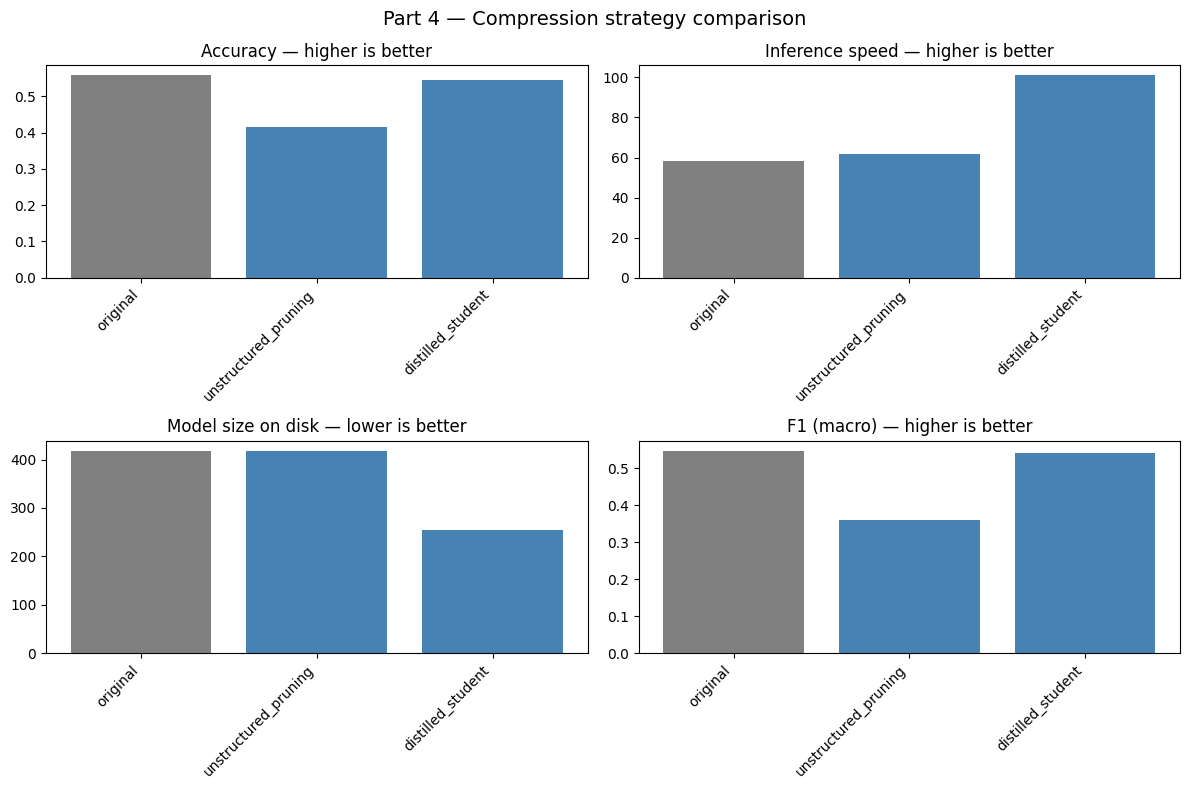

Saved figure to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/figures/compression_comparison.png


In [17]:
## 2x2 bar chart: performance (Accuracy) vs efficiency (speed, size, carbon)
## original drawn in grey as the reference; other variants in blue
methods = comparison_df["Method"].tolist()
colors  = ["grey" if m == "original" else "steelblue" for m in methods]

panels = [
    ("Accuracy",            "Accuracy — higher is better"),
    ("Speed (samples/sec)", "Inference speed — higher is better"),
    ("Size (MB)",           "Model size on disk — lower is better"),
    ("F1 (macro)",            "F1 (macro) — higher is better"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title) in zip(axes.ravel(), panels):
    ax.bar(methods, comparison_df[col], color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

fig.suptitle("Part 4 — Compression strategy comparison", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "compression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'compression_comparison.png'}")

### Key findings / Observations:

**the distilled model is the clear winner**
* it's accuracy hovers at around 55% - very close/if not the same as the teacher model
* it's nearly double as fast as the original model when it comes to inference
* it's smaller on disk
* and it has marginally better F1 score
* all with 67M parameters instead of ~110M.

**On the other methods tried, pruning along yields counterintuitive results.**
1. *unstructured pruning.* accuracy drops, inference isn't much better, size is the about the same...and F1 score drops. soo it actually did worse while not being any smaller or faster.
2. *dynamic pruning.* kept accurace and F1 score nearly the same as the teacher model, but it took longer to run...this was supposed to run faster (that is why it is liked), but with my laptop it moved mroe slowly because my hardware (is notorisouly a pain) and lacks INT8 kernels which dynamic pruning relies on to have the expectd speed up. *Important Note* - in the current run on GPU, the dynamic pruning couldn't be run. Below we've included the results from a previous CPU run. It was from this run that we created this comment.

All in all, while distillation can take a bit of time, it seems to perform well. This can be sped up if we have the teacher model saved, so overall, intuitive and more deployable than quantization in this case (with the hardware at hand and data in question).

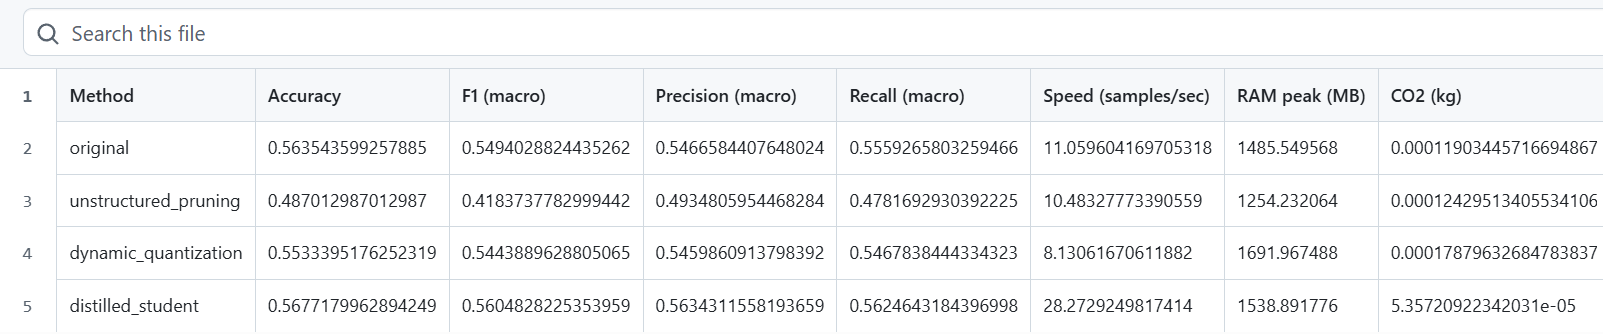

## Subquestion c — Error analysis

Here we go one level deeper and look at *which classes* each compression strategy hurts, using per-sample predictions on the **same test split** used everywhere else. This is important as in a previous run we had pulled the best BERT but redone the test/train split data and this led to data leakage. We've now revised the logic so that Part 3 itself outputs the data we should pull to Part 4. This is relevant for this entire section, but commented here as this is where we saw that something had gone wrong.

We don't re-run any inference here. The eval harness (`measure_inference_metrics`) already makes one forward pass per variant when benchmarking it, so `evaluate_variant` stashes those per-sample predictions into `variant_preds` (and mirrors them to `results/part4_variant_preds.npz`).

We then build (1) side-by-side **confusion matrices**, (2) a **per-class F1** table with the change vs the original, and (3) a short-vs-long-review accuracy breakdown (which links to some of the insights seen in part 1).


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

## Per-sample predictions were already captured during evaluate_variant (the single forward pass
## measure_inference_metrics makes for each variant), so there is NO second inference here — no
## teacher reload, no re-smash. If the kernel was restarted and variant_preds is empty, reload the
## stashed predictions from the .npz instead of re-running every model.
if not variant_preds:
    print(f"variant_preds empty (kernel restart?) — reloading from {PREDS_FILE.name}")
    with np.load(PREDS_FILE) as npz:
        pred_labels = npz["__labels__"]
        loaded = {k: npz[k] for k in npz.files if k != "__labels__"}
    ## keep 'original' first so the per-class delta / confusion-matrix layout matches Subquestion b
    order = ["original"] + [k for k in loaded if k != "original"]
    variant_preds = {k: loaded[k] for k in order if k in loaded}

y_true = np.asarray(pred_labels if pred_labels is not None else valid_labels)

## sanity: these reuse the benchmarked models' own predictions, so the recomputed macro-F1 must
## match the comparison table from Subquestion b exactly (no rebuilt-model drift to worry about).
print("Reusing predictions from the benchmark pass (no re-inference).")
print("Recomputed F1(macro) should match the comparison table:")
for name, preds in variant_preds.items():
    print(f"  {name:22s} F1(macro)={f1_score(y_true, preds, average='macro'):.4f}")
    print(f"  {name:22s} Accuracy ={accuracy_score(y_true, preds):.4f}")
    print()

Reusing predictions from the benchmark pass (no re-inference).
Recomputed F1(macro) should match the comparison table:
  original               F1(macro)=0.5475
  original               Accuracy =0.5575

  unstructured_pruning   F1(macro)=0.3610
  unstructured_pruning   Accuracy =0.4160

  distilled_student      F1(macro)=0.5415
  distilled_student      Accuracy =0.5450



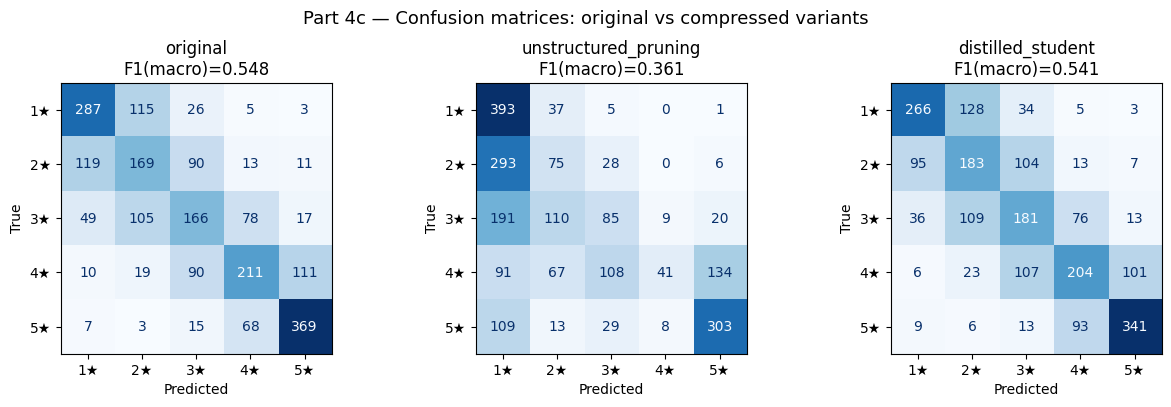

Saved figure to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/figures/confusion_matrices.png


In [19]:
## side-by-side confusion matrices: original vs each compressed variant
## label i corresponds to (i+1) stars
STAR_LABELS = [f"{i + 1}★" for i in range(num_labels)]

n = len(variant_preds)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.0))
if n == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, variant_preds.items()):
    cm = confusion_matrix(y_true, preds, labels=range(num_labels))
    ConfusionMatrixDisplay(cm, display_labels=STAR_LABELS).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format="d"
    )
    ax.set_title(f"{name}\nF1(macro)={f1_score(y_true, preds, average='macro'):.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.suptitle("Part 4c — Confusion matrices: original vs compressed variants", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'confusion_matrices.png'}")


The confusion matrix are in line with what we expect - the models find it "easy" to predict 1 and 5 stars, but struggle more with the middle. Also in line with the literature, most predictions for teacher, dyanmic and distilled student are 1-away from the true label. We confirmed this more clearly in the tables and plots below.

interestingly, the distilled model appears to be better at correctly predicting the middle ratings - we first trained it on 3 epochs and now on 5 epochs and in both cases, the distilled model did well on the middle ratings, relative to the other models.

### How *far off* are the errors? (ordinal error distance)

Following Pang & Lee's *Seeing Stars*, we treat the labels as a metric scale where distance `d(ℓ, ℓ′) = |ℓ − ℓ′|` — "three stars is closer to four stars than to one star." So not all errors are equal: an off-by-1 is a near-miss, while an off-by-3+ is a genuine polarity confusion (e.g. predicting 1★ for a 4★ review).

For every model version we bucket the erros into **1 / 2 / 3+ away** (folding 3 and 4 together in our case). Note that the "Seeing Stars"'s Table 1 conditions on a distance known a priori — they show annotators pairs N notches apart. Here the distance only exists after an error, so this is an adaptation of their framing, not the identical table.

In [20]:
# Off-by-N error analysis — how *far* are the wrong predictions?
# MAE = mean |pred - true| is the single distance-aware summary the buckets decompose (their L1 error).
def offby_counts(preds):
    dist  = np.abs(preds - y_true)
    wrong = dist[dist > 0]
    c1 = int((wrong == 1).sum())
    c2 = int((wrong == 2).sum())
    c3 = int((wrong >= 3).sum())            # fold 3 and 4 together
    return c1, c2, c3, int(wrong.size)

# numeric tables (for the stacked bars + CSV) plus a display table in the paper's "% (N)" style:
# one cell carries both the share-of-errors and the raw count, mirroring Seeing Stars' Table 1.
count_rows, pct_rows, display_rows = [], [], []
for name, preds in variant_preds.items():
    c1, c2, c3, n_err = offby_counts(preds)
    mae    = float(np.abs(preds - y_true).mean())
    counts = [c1, c2, c3]
    pcts   = [100 * c / n_err if n_err else 0.0 for c in counts]    # share of THIS model's errors
    count_rows.append({"Method": name, "1 away": c1, "2 away": c2, "3+ away": c3})
    pct_rows.append({"Method": name, "1 away": pcts[0], "2 away": pcts[1], "3+ away": pcts[2]})
    display_rows.append({
        "Method":      name,
        "Errors (n)":  n_err,
        "MAE":         round(mae, 3),
        "1 away":      f"{pcts[0]:.1f}% ({c1})",
        "2 away":      f"{pcts[1]:.1f}% ({c2})",
        "3+ away":     f"{pcts[2]:.1f}% ({c3})",
    })

offby_counts_df  = pd.DataFrame(count_rows).set_index("Method")     # raw counts -> absolute bars
offby_pct_df     = pd.DataFrame(pct_rows).set_index("Method")       # % of errors -> normalised bars
offby_display_df = pd.DataFrame(display_rows)                       # "% (N)" table for the report

# persist a numeric view (counts + total errors + MAE) for the report / write-up
csv_out = offby_counts_df.copy()
csv_out.insert(0, "Errors (n)", offby_counts_df.sum(axis=1))
csv_out["MAE"] = [round(float(np.abs(p - y_true).mean()), 4) for p in variant_preds.values()]
csv_out.to_csv(RESULTS_DIR / "part4_offby_n.csv")
print(f"Saved off-by-N breakdown to {RESULTS_DIR / 'part4_offby_n.csv'}")

print("\nOff-by-N error distance — % of each model's errors (raw count in parens):")
display(offby_display_df)

Saved off-by-N breakdown to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/results/part4_offby_n.csv

Off-by-N error distance — % of each model's errors (raw count in parens):


,Method,Errors (n),MAE,1 away,2 away,3+ away
0,original,954,0.548,81.3% (776),14.6% (139),4.1% (39)
1,unstructured_pruning,1259,0.984,57.7% (727),24.8% (312),17.5% (220)
2,distilled_student,981,0.555,82.9% (813),13.5% (132),3.7% (36)


~80% of original, dynamic and distilled models' errors are +- 1 star from the true label. ¬96.3% of the errors are within 2 stars, a tiny bit better than the teacher model at 95.9%. The unstructured pruning one performs significantly worse in this run, with 17.5% of the errors 3+ stars away. 


![image.png](attachment:image.png)

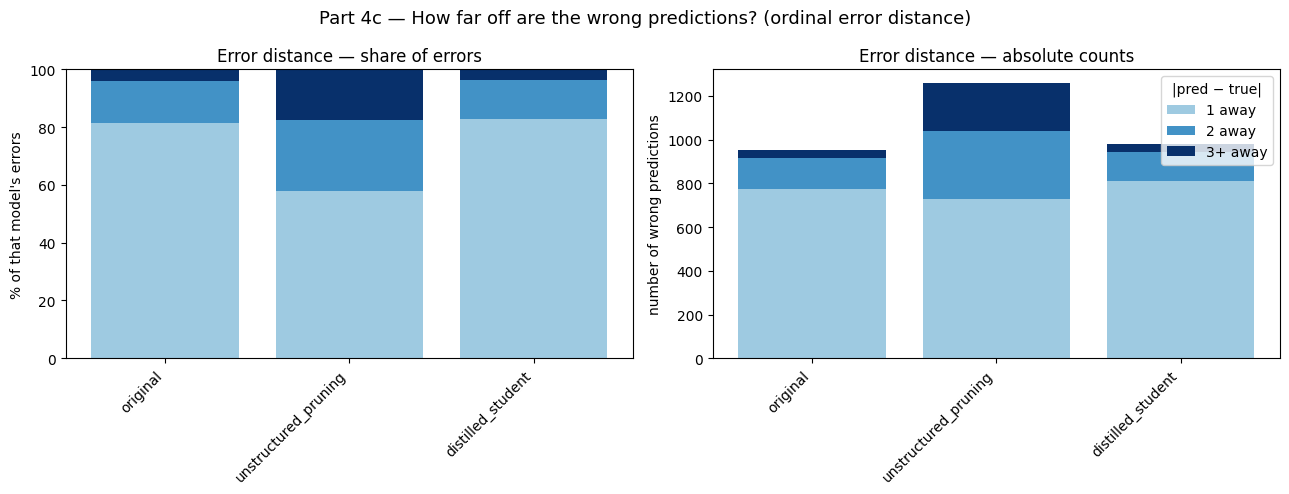

Saved figure to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/figures/offby_n_distance.png


In [21]:
# Two stacked-bar views of the same off-by-N breakdown:
##   left  — share of EACH model's errors (normalised: "when it's wrong, how wrong?")
##   right — absolute error counts (a model with fewer total errors has shorter bars)

methods    = offby_counts_df.index.tolist()
seg_names  = ["1 away", "2 away", "3+ away"]
seg_colors = ["#9ecae1", "#4292c6", "#08306b"]      # light -> dark blue

fig, (ax_pct, ax_abs) = plt.subplots(1, 2, figsize=(13, 5))

## left: % of each model's errors (every bar sums to 100%)
bottom = np.zeros(len(methods))
for seg, color in zip(seg_names, seg_colors):
    vals = offby_pct_df[seg].values
    ax_pct.bar(methods, vals, bottom=bottom, color=color, label=seg)
    bottom += vals
ax_pct.set_ylabel("% of that model's errors")
ax_pct.set_ylim(0, 100)
ax_pct.set_title("Error distance — share of errors")

## right: absolute counts (raw number of wrong predictions at each distance)
bottom = np.zeros(len(methods))
for seg, color in zip(seg_names, seg_colors):
    vals = offby_counts_df[seg].values
    ax_abs.bar(methods, vals, bottom=bottom, color=color, label=seg)
    bottom += vals
ax_abs.set_ylabel("number of wrong predictions")
ax_abs.set_title("Error distance — absolute counts")

for ax in (ax_pct, ax_abs):
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
ax_abs.legend(title="|pred − true|", loc="upper right")

fig.suptitle("Part 4c — How far off are the wrong predictions? (ordinal error distance)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "offby_n_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'offby_n_distance.png'}")

In [22]:
## per-class F1 for every variant + the change vs the original
## (which star rating does each compression strategy hurt most?)
per_class = {
    name: f1_score(y_true, preds, average=None, labels=range(num_labels))
    for name, preds in variant_preds.items()
}
perclass_df = pd.DataFrame(per_class, index=STAR_LABELS)
perclass_df.index.name = "Class"

## Delta vs original: negative = that class got worse under the variant
delta_df = perclass_df.subtract(perclass_df["original"], axis=0)

perclass_df.round(4).to_csv(RESULTS_DIR / "part4_perclass_f1.csv")
delta_df.round(4).to_csv(RESULTS_DIR / "part4_perclass_f1_delta.csv")

print("Per-class F1:")
display(perclass_df.round(3))
print("\nDelta per-class F1 vs original (negative = degraded):")
display(delta_df.round(3))

## worst-hit class per compressed variant
print("\nWorst-hit class per variant (largest F1 drop vs original):")
for name in variant_preds:
    if name == "original":
        continue
    print(f"  {name:22s} -> {delta_df[name].idxmin()}  (Δ F1 = {delta_df[name].min():+.3f})")


Per-class F1:


,original,unstructured_pruning,distilled_student
Class,,,
1★,0.632,0.519,0.627
2★,0.416,0.213,0.430
3★,0.414,0.254,0.424
4★,0.517,0.164,0.490
5★,0.758,0.654,0.736



Delta per-class F1 vs original (negative = degraded):


,original,unstructured_pruning,distilled_student
Class,,,
1★,0.0,-0.113,-0.005
2★,0.0,-0.203,0.014
3★,0.0,-0.160,0.010
4★,0.0,-0.353,-0.027
5★,0.0,-0.104,-0.023



Worst-hit class per variant (largest F1 drop vs original):
  unstructured_pruning   -> 4★  (Δ F1 = -0.353)
  distilled_student      -> 4★  (Δ F1 = -0.027)


Interestingly - when we look at specific rating prediction. The distilled model performs better on the "harder" to predict ones in the middle than the teacher model. This implies that the model leverages what the teacher has learned and is able to further refine how it destinguishes between those stars. 

it is also worth noting that the improvement in results for 2 and 3 comes at a cost for 1,4 and 5. Future work should look into what the Recursive deep models with sentiment did as adding sentiment via embedding will most likely help distinguish more.

In [ ]:
## does compression hurt short or long reviews more?
## ordinal star rating is harder with less context, so split the test set at the median length
lengths    = np.array([len(t.split()) for t in valid_texts])
median_len = np.median(lengths)
short_mask = lengths <= median_len          # shorter half (fewer words = less context)

print(f"Median review length: {median_len:.0f} words "
      f"| short n={short_mask.sum()}  long n={(~short_mask).sum()}")

rows = []
for name, preds in variant_preds.items():
    acc_short = (preds[short_mask]  == y_true[short_mask]).mean()
    acc_long  = (preds[~short_mask] == y_true[~short_mask]).mean()
    rows.append({
        "Method": name,
        "Acc (short reviews)": round(acc_short, 4),
        "Acc (long reviews)":  round(acc_long, 4),
        "Long - short":        round(acc_long - acc_short, 4),
    })

length_df = pd.DataFrame(rows)
length_df.to_csv(RESULTS_DIR / "part4_accuracy_by_length.csv", index=False)
print(f"Saved length breakdown to {RESULTS_DIR / 'part4_accuracy_by_length.csv'}")
length_df


Median review length: 56 words | short n=1079  long n=1077
Saved length breakdown to /Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/results/part4_accuracy_by_length.csv


,Method,Acc (short reviews),Acc (long reviews),Long - short
0,original,0.5950,0.5200,-0.0750
1,unstructured_pruning,0.4198,0.4123,-0.0076
2,distilled_student,0.5681,0.5218,-0.0463


Confirming intuition, modestly. Shorter reviews are easier to classify correctly across all three models and especially so for the teacher and distilled model.

for the distilled student, the difference is 4% in accuracy, which isn't negligible.

## Deficiencies & Future Work — closing the gap to SOTA

Our distilled student is the best model we produced with 56.77% accuracy, 0.5605 F1 macro, 2x faster, 40% smaller, but it's still ~14% worse than SentiLARE's 71.57% on Yelp-5 (Ke et al., 2020). These are some of the main reasons it breaks down along with what we would do next to address it.

1. **The teacher ceiling is the binding constraint.** Distillation can't signficantly outperform its source of knowledge. Our teacher lands at 56.35% accuracy / 0.5494 F1, so the student matching (and slightly beating) it at 56.77% actually means distillation worked well. If we were able to produce a stronger teacher, we believe we'd produce a stronger student as well. Additionally, training for more epochs (we were capped at 3 due to CPU), using a learning rate scheduler with warmup (as was noted in one of the literature papers), and running on GPU would all help — our code already has the flags for this (time allowing we will rerun this all in another laptop, in which case we expect to see better performance).
2. **Data scale: ~10K samples vs 100k samples vs millions**. As mentioned in Part 3: SentiLARE pre-trains on 6.7M Yelp reviews before fine-tuning. We're working with ~10,780 labeled examples from just 2 Trustpilot categories (Travel & Vacation, Media & Publishing). Significantly less data. We could've / in the future expand(ed) to all Trustpilot categories, even without labels, given the 32 labels contraints. This would give the teacher model much richer representations of review language before it ever sees a star rating and therefore pass on better learnings to the distilled model.
3. **No sentiment-aware representations.** This is already mentioned in Part 3, but again, something that would've helped our student model.
4. **Ordinal structure is ignored in the loss.** Most of our errors are off-by-1, which is good, but the cross-entropy loss doesn't reward near-misses. Confusing 1-5 is not the same as confusing 1-2. Switching to an ordinal-aware loss, e.g., CORN (Shi et al., 2021) or a simple MSE regression head on top of the [CLS] embedding — could push the middle ratings (2–4★) where we struggle most. Our confusion matrices show the same pattern — 1★ and 5★ are "easy" (F1 of 0.651 and 0.757), while 2–4★ are muddled. Even though we did data augmentation, we could create more augmented reviews that focus on the 2-4 review zone (having sentences that were more nuanced or used negations / contradictions within a compliment) so our model can learn more. Note that our early SetFit experiment hit ~70% accuracy with just 32 labeled samples + synthetic data, which suggests that the signal is there in the text, we're just not extracting it efficiently enough with the current architecture.
5. **Short reviews lose more accuracy across the board**. **The length breakdown shows all models do worse on long reviews** (counter-intuitive at first — more context should help). But this likely reflects the fact that longer Trustpilot reviews tend to be more mixed/nuanced (complaining about one thing, praising another), making the single star label harder to predict. Hierarchical or aspect-level approaches — splitting long reviews into aspect segments before classifying — could help the model handle these multi-sentiment documents - this is exactly what the paper: Recursive Deep Models for Semantic Composionality looked at.
   
In short: there are only a couple things we can do to improve the distilled/student model alone. Most of the steps highlighted above apply first to the teacher model. Therefore, improving the performance of the teacher model is the single best thing to do to improve the performance of the student model. For the student model, once optimized per the teacher model, can be improved in terms of efficiency and size so that it balances performance against non-inference metrics, such as size and speed (which ultimately impacts its deployability).